# Assignment: Hypothesis Testing using Language Models
## Question 3

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import string, re, os
from collections import Counter
from scipy.stats import pearsonr
from scipy import stats as sci_stats
import warnings

warnings.filterwarnings("ignore")

BNC_CSV = "../bnc.csv"
BROWN_TRAIN = "../browndata/brown-train.txt"
BROWN_DEV = "../browndata/brown-dev.txt"
BROWN_TEST = "../browndata/brown-test.txt"

print("Libraries loaded.")

Libraries loaded.


## 1. Load and Combine Datasets

In [2]:
bnc = pd.read_csv(BNC_CSV, sep="\t")
bnc_sentences = bnc["text"].str.lower().tolist()
print(f"BNC: {len(bnc_sentences):,} sentences")

brown_sentences = []
for path in [BROWN_TRAIN, BROWN_DEV, BROWN_TEST]:
    if not os.path.exists(path):
        print(f"WARNING: {path} not found — skipping.")
        continue
    with open(path, encoding="utf-8", errors="ignore") as f:
        lines = [l.strip().lower() for l in f if l.strip()]
    brown_sentences.extend(lines)
    print(f"  {path}: {len(lines):,} lines")

print(f"\nBrown total: {len(brown_sentences):,} lines")

BNC: 5,250 sentences


  ../browndata/brown-train.txt: 37,272 lines
  ../browndata/brown-dev.txt: 5,734 lines
  ../browndata/brown-test.txt: 14,334 lines

Brown total: 57,340 lines


In [3]:
PUNCT = set(string.punctuation)


def is_non_punct_word(token):
    """Return True if token has at least one alphabetic character."""
    return any(c.isalpha() for c in token)


def tokenize(sentence):
    """Simple whitespace tokeniser; keeps only non-punctuation tokens."""
    tokens = sentence.split()
    return [t.strip(string.punctuation) for t in tokens if is_non_punct_word(t)]


all_tokens = []
for sent in bnc_sentences + brown_sentences:
    all_tokens.extend(tokenize(sent))

print(f"Total tokens (non-punct): {len(all_tokens):,}")

Total tokens (non-punct): 1,087,031


## 2. Build Word-Level Statistics

In [4]:
freq_counter = Counter(all_tokens)
total_tokens = sum(freq_counter.values())

word_data = []
for word, freq in freq_counter.items():
    length = len(word)  # number of letters (non-punct characters)
    prob = freq / total_tokens
    ic = -np.log2(prob)  # information content (surprisal)
    word_data.append(
        {"word": word, "length": length, "frequency": freq, "prob": prob, "IC": ic}
    )

df = pd.DataFrame(word_data)
df = df[df["length"] > 0]  # drop any empty strings
df = df.sort_values("frequency", ascending=False).reset_index(drop=True)

print(f"Unique words: {len(df):,}")
print(f"Total tokens: {total_tokens:,}")
df.head(10)

Unique words: 48,288
Total tokens: 1,087,031


,word,length,frequency,prob,IC
0,the,3,75207,0.069186,3.853382
1,of,2,39164,0.036028,4.794721
2,and,3,31110,0.028619,5.126871
3,to,2,28397,0.026123,5.258511
4,a,1,25272,0.023249,5.426709
5,in,2,23180,0.021324,5.551369
6,is,2,11354,0.010445,6.581049
7,that,4,11241,0.010341,6.595479
8,was,3,10549,0.009704,6.687143
9,for,3,10168,0.009354,6.740213


## 3. Word Length in Letters

In [5]:
print(df[["word", "length", "frequency", "IC"]].head(10).to_string(index=False))
print("\nLength statistics:")
print(df["length"].describe())

word  length  frequency       IC
 the       3      75207 3.853382
  of       2      39164 4.794721
 and       3      31110 5.126871
  to       2      28397 5.258511
   a       1      25272 5.426709
  in       2      23180 5.551369
  is       2      11354 6.581049
that       4      11241 6.595479
 was       3      10549 6.687143
 for       3      10168 6.740213

Length statistics:
count    48288.000000
mean         8.198869
std          2.916235
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         32.000000
Name: length, dtype: float64


## 4. Histogram of Word Lengths

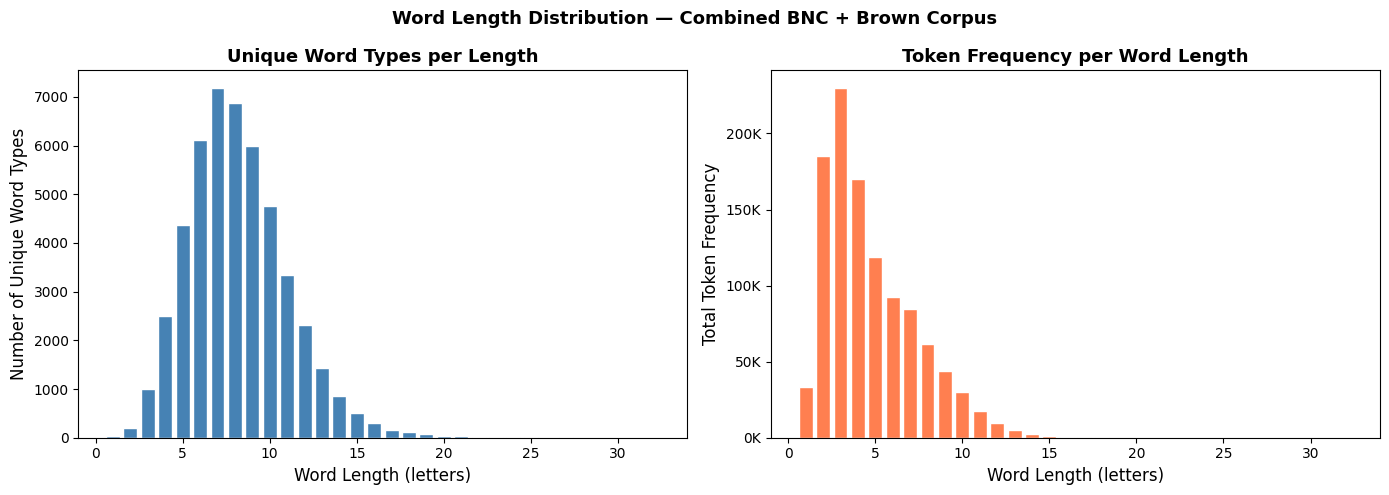

In [6]:
length_counts = df.groupby("length")["frequency"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: count of unique word types per length
type_counts = df["length"].value_counts().sort_index()
axes[0].bar(type_counts.index, type_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Word Length (letters)", fontsize=12)
axes[0].set_ylabel("Number of Unique Word Types", fontsize=12)
axes[0].set_title("Unique Word Types per Length", fontsize=13, fontweight="bold")

axes[1].bar(length_counts.index, length_counts.values, color="coral", edgecolor="white")
axes[1].set_xlabel("Word Length (letters)", fontsize=12)
axes[1].set_ylabel("Total Token Frequency", fontsize=12)
axes[1].set_title("Token Frequency per Word Length", fontsize=13, fontweight="bold")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

plt.suptitle(
    "Word Length Distribution — Combined BNC + Brown Corpus",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("word_length_histogram.png", dpi=150)
plt.show()

## 5. Regression: IC vs Frequency as Predictors of Word Length

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

y = df["length"].values.reshape(-1, 1)

X_ic = df["IC"].values.reshape(-1, 1)
X_freq = df["frequency"].values.reshape(-1, 1)
X_logfreq = np.log10(df["frequency"]).values.reshape(-1, 1)

models = {
    "IC (surprisal)": X_ic,
    "Raw Frequency": X_freq,
    "log10(Frequency)": X_logfreq,
}

print(f"{'Model':<25} {'R²':>8}  {'Adj-R²':>9}  {'Slope':>9}  {'Intercept':>10}")
print("-" * 70)

reg_results = {}
for name, X in models.items():
    reg = LinearRegression().fit(X, y.ravel())
    pred = reg.predict(X)
    r2 = r2_score(y.ravel(), pred)
    n, p = len(y), 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    reg_results[name] = {"model": reg, "R2": r2, "adjR2": adj_r2, "X": X}
    print(
        f"{name:<25} {r2:>8.4f}  {adj_r2:>9.4f}  "
        f"{reg.coef_[0]:>9.4f}  {reg.intercept_:>10.4f}"
    )

Model                           R²     Adj-R²      Slope   Intercept
----------------------------------------------------------------------
IC (surprisal)              0.0667     0.0667     0.3847      1.1058
Raw Frequency               0.0029     0.0029    -0.0003      8.2061
log10(Frequency)            0.0667     0.0667    -1.2778      8.8189


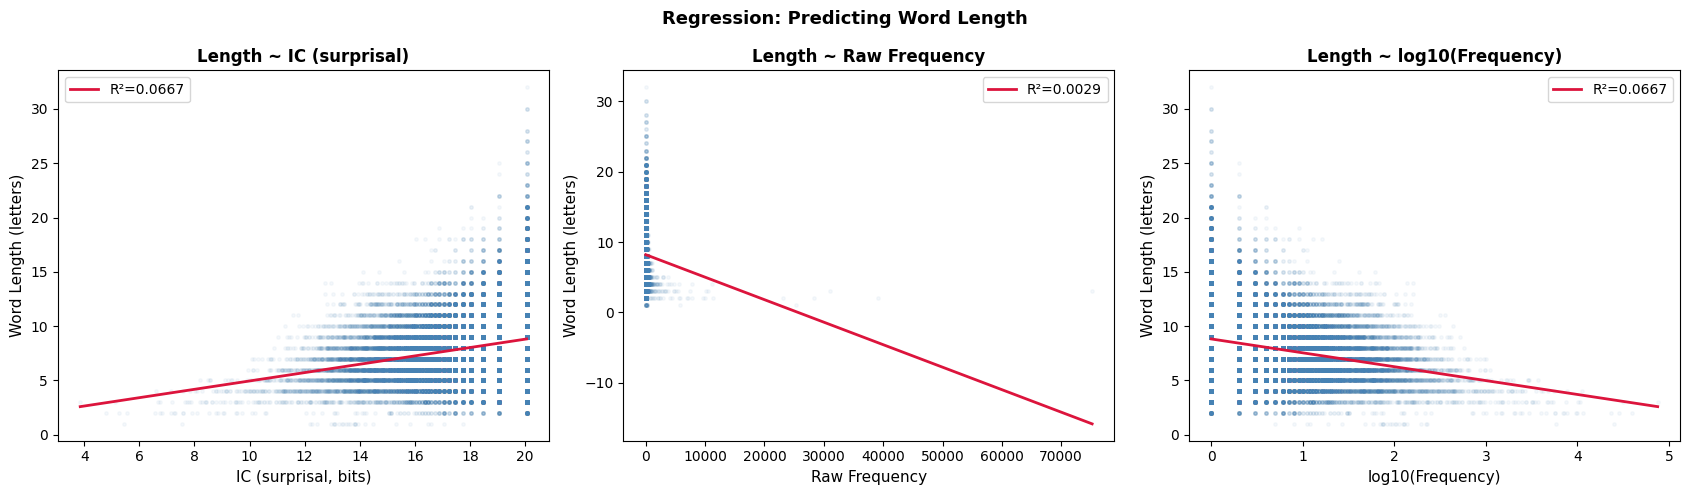


--- Interpretation ---
IC R² = 0.0667  |  log-Freq R² = 0.0667
→ log10(Frequency) has better fit to the data.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles_x = ["IC (surprisal, bits)", "Raw Frequency", "log10(Frequency)"]

for ax, (name, res), xlabel in zip(axes, reg_results.items(), titles_x):
    X = res["X"].ravel()
    ax.scatter(X, y.ravel(), alpha=0.05, s=6, color="steelblue")
    xs = np.linspace(X.min(), X.max(), 200)
    ax.plot(
        xs,
        res["model"].predict(xs.reshape(-1, 1)),
        color="crimson",
        lw=2,
        label=f"R²={res['R2']:.4f}",
    )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Word Length (letters)", fontsize=11)
    ax.set_title(f"Length ~ {name}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)

plt.suptitle("Regression: Predicting Word Length", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regression_length.png", dpi=150)
plt.show()

print("\n--- Interpretation ---")
ic_r2 = reg_results["IC (surprisal)"]["R2"]
freq_r2 = reg_results["Raw Frequency"]["R2"]
lf_r2 = reg_results["log10(Frequency)"]["R2"]
winner = "IC" if ic_r2 > lf_r2 else "log10(Frequency)"
print(f"IC R² = {ic_r2:.4f}  |  log-Freq R² = {lf_r2:.4f}")
print(f"→ {winner} has better fit to the data.")

## 6. [1 mark] Shortest Words

In [9]:
shortest = df[df["length"] == df["length"].min()].sort_values(
    "frequency", ascending=False
)

print(f"Minimum word length: {df['length'].min()} letter(s)")
print("\nShortest words (sorted by frequency):")
print(shortest[["word", "length", "frequency"]].to_string(index=False))

Minimum word length: 1 letter(s)

Shortest words (sorted by frequency):
word  length  frequency
   a       1      25272
   i       1       5835
   c       1        230
   s       1        220
   b       1        196
   p       1        137
   j       1        126
   e       1        126
   d       1        125
   t       1        113
   r       1        104
   f       1        101
   h       1         94
   w       1         89
   m       1         84
   o       1         76
   u       1         75
   n       1         75
   l       1         74
   g       1         69
   v       1         58
   q       1         48
   k       1         27
   x       1         19
   y       1         12
   γ       1         11
   α       1          8
   z       1          5


## 7. [1 mark] Pearson Correlation: Length vs. Frequency

In [10]:
r_lf, p_lf = pearsonr(df["length"], df["frequency"])
r_ll, p_ll = pearsonr(df["length"], np.log10(df["frequency"]))

print(f"Pearson r (length vs frequency):          r = {r_lf:.4f},  p = {p_lf:.4e}")
print(f"Pearson r (length vs log10 frequency):    r = {r_ll:.4f},  p = {p_ll:.4e}")

Pearson r (length vs frequency):          r = -0.0541,  p = 1.2553e-32
Pearson r (length vs log10 frequency):    r = -0.2583,  p = 0.0000e+00


## 8. [2 marks] Plot: Length (X) vs. Frequency (Y)

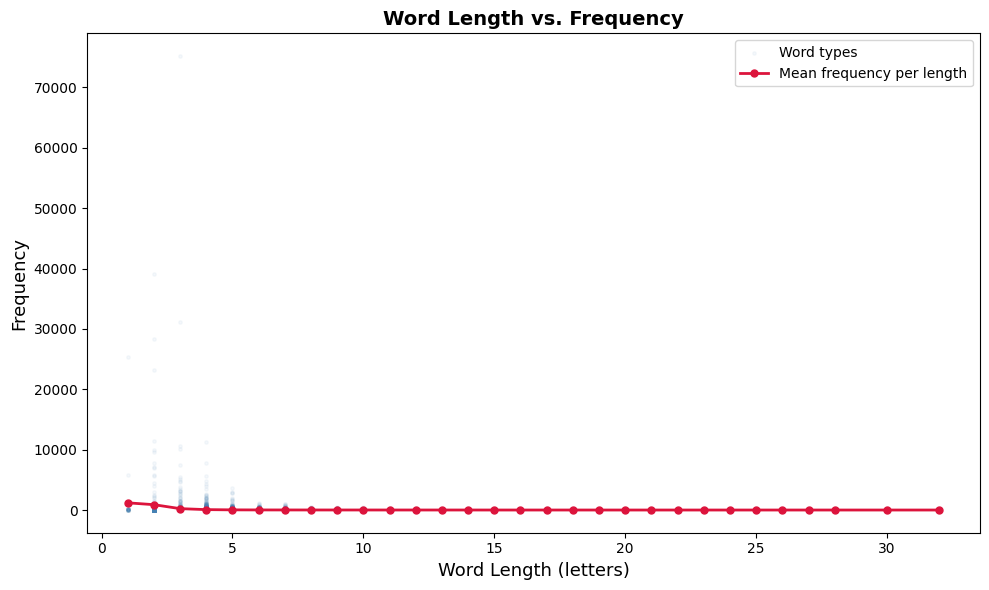

In [11]:
agg = (
    df.groupby("length")
    .agg(mean_freq=("frequency", "mean"), total_freq=("frequency", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df["length"],
    df["frequency"],
    alpha=0.05,
    s=6,
    color="steelblue",
    label="Word types",
)
ax.plot(
    agg["length"],
    agg["mean_freq"],
    color="crimson",
    lw=2,
    marker="o",
    markersize=5,
    label="Mean frequency per length",
)

ax.set_xlabel("Word Length (letters)", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.set_title("Word Length vs. Frequency", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("length_vs_freq.png", dpi=150)
plt.show()

## 9. [2 marks] Plot: log10(Length) vs. log10(Frequency)

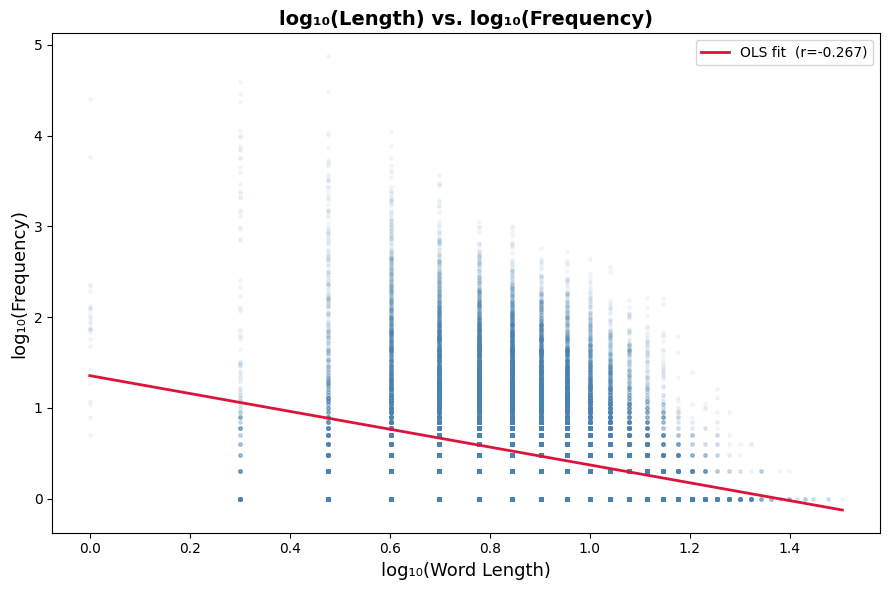

OLS slope = -0.983  (negative → shorter = more frequent)


In [12]:
log_len = np.log10(df["length"])
log_freq = np.log10(df["frequency"])

slope, intercept, r_val, p_val, stderr = sci_stats.linregress(log_len, log_freq)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(log_len, log_freq, alpha=0.05, s=6, color="steelblue")
xs = np.linspace(log_len.min(), log_len.max(), 200)
ax.plot(
    xs, slope * xs + intercept, color="crimson", lw=2, label=f"OLS fit  (r={r_val:.3f})"
)

ax.set_xlabel("log₁₀(Word Length)", fontsize=13)
ax.set_ylabel("log₁₀(Frequency)", fontsize=13)
ax.set_title("log₁₀(Length) vs. log₁₀(Frequency)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("loglog_length_freq.png", dpi=150)
plt.show()
print(f"OLS slope = {slope:.3f}  (negative → shorter = more frequent)")

## 10. [2 marks] Plot: log10(Length) vs. Information Content (IC)

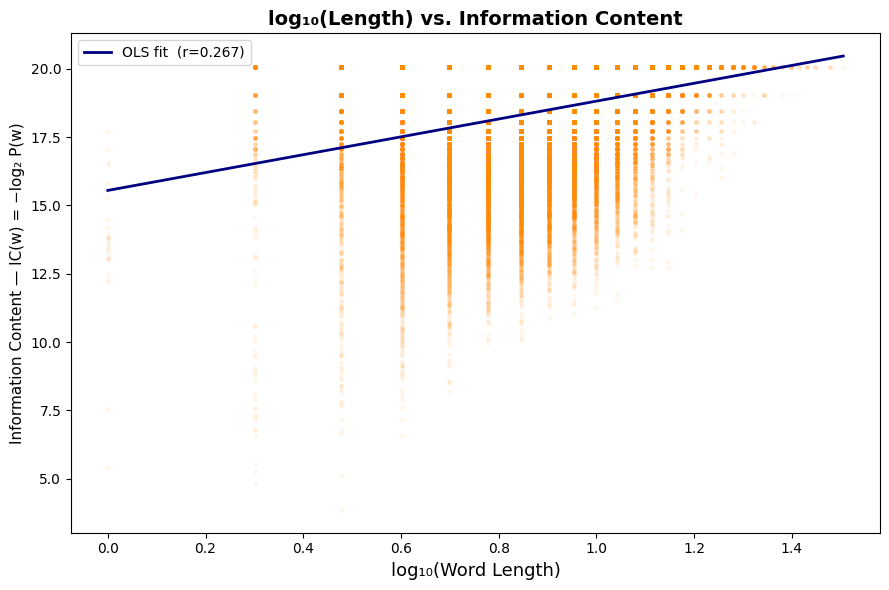

OLS slope = 3.267  (positive → longer words carry more information)


In [13]:
log_len = np.log10(df["length"])
ic = df["IC"]

slope2, intercept2, r2_val, _, _ = sci_stats.linregress(log_len, ic)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(log_len, ic, alpha=0.05, s=6, color="darkorange")
xs = np.linspace(log_len.min(), log_len.max(), 200)
ax.plot(
    xs, slope2 * xs + intercept2, color="navy", lw=2, label=f"OLS fit  (r={r2_val:.3f})"
)

ax.set_xlabel("log₁₀(Word Length)", fontsize=13)
ax.set_ylabel("Information Content — IC(w) = −log₂ P(w)", fontsize=11)
ax.set_title("log₁₀(Length) vs. Information Content", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("loglen_vs_ic.png", dpi=150)
plt.show()
print(f"OLS slope = {slope2:.3f}  (positive → longer words carry more information)")